In [1]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
VIDEO_PATH = Path("assets/cup.mp4")
STABILIZED_PATH = Path("outputs/cup_robust_stabilized.mp4")
CROPPED_PATH = Path("outputs/cup_robust_stabilized_cropped.mp4")

In [20]:
# Size of the template selected from the first frame.
# You can change this if necessary.
TEMPLATE_WIDTH = 40
TEMPLATE_HEIGHT = 40

# Search area around the previous template position.
ROI_WIDTH = 800
ROI_HEIGHT = 800

# Matching threshold.
MATCH_THRESHOLD = 0.55

# Display scale.
DISPLAY_SCALE = 0.5

In [21]:
cap = cv2.VideoCapture(str(VIDEO_PATH))

if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {VIDEO_PATH}")

fps = cap.get(cv2.CAP_PROP_FPS)

frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))

frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

if fps <= 0:
    fps = 30.0

print(f"FPS: {fps}")
print(f"Resolution: {frame_width} x {frame_height}")
print(f"Frames: {frame_count}")

FPS: 29.27541614807962
Resolution: 1080 x 1920
Frames: 282


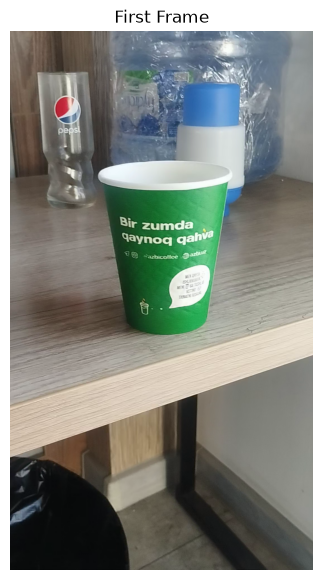

In [22]:
ret, first_frame = cap.read()

if not ret:
    cap.release()
    raise RuntimeError("Could not read the first frame.")

first_frame_rgb = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 7))
plt.imshow(first_frame_rgb)
plt.axis("off")
plt.title("First Frame")
plt.show()

In [23]:
print("Select a distinctive part of the CUP.")
print("Press ENTER or SPACE after selection.")
print("Press C to cancel.")

display_frame = cv2.resize(
    first_frame,
    None,
    fx=DISPLAY_SCALE,
    fy=DISPLAY_SCALE
)

x, y, w, h = cv2.selectROI(
    "Select Cup Template",
    display_frame,
    fromCenter=False,
    showCrosshair=True
)

cv2.destroyAllWindows()

Select a distinctive part of the CUP.
Press ENTER or SPACE after selection.
Press C to cancel.


In [24]:
# Convert ROI coordinates back to original resolution.

x = int(x / DISPLAY_SCALE)
y = int(y / DISPLAY_SCALE)
w = int(w / DISPLAY_SCALE)
h = int(h / DISPLAY_SCALE)

if w == 0 or h == 0:
    raise RuntimeError("No template was selected.")

print(
    f"Selected template: "
    f"x={x}, y={y}, w={w}, h={h}"
)

Selected template: x=294, y=438, w=510, h=660


In [25]:
template = first_frame[y:y+h, x:x+w].copy()

template_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)

template_h, template_w = template_gray.shape

print(
    f"Template size: "
    f"{template_w} x {template_h}"
)

Template size: 510 x 660


In [26]:
def create_search_roi(
    frame_width,
    frame_height,
    template_x,
    template_y,
    template_w,
    template_h,
    roi_width,
    roi_height
):
    center_x = template_x + (template_w // 2)
    center_y = template_y + (template_h // 2)

    roi_x1 = center_x - (roi_width//2)
    roi_y1 = center_y - (roi_height//2)

    roi_x2 = roi_x1 + roi_width
    roi_y2 = roi_y1 + roi_height

    roi_x1 = max(0, roi_x1)
    roi_y1 = max(0, roi_y1)

    roi_x2 = min(frame_width, roi_x2)
    roi_y2 = min(frame_height, roi_y2)

    return roi_x1, roi_y1, roi_x2, roi_y2

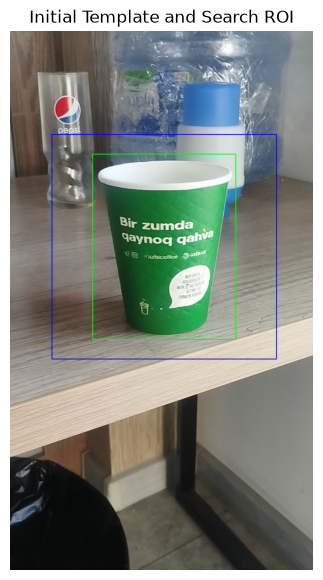

In [27]:
roi_x1, roi_y1, roi_x2, roi_y2 = (
    create_search_roi(
        frame_width,
        frame_height,
        x,
        y,
        template_w,
        template_h,
        ROI_WIDTH,
        ROI_HEIGHT
    )
)

preview = first_frame.copy()

# Template
cv2.rectangle(
    preview,
    (x, y),
    (
        x + template_w,
        y + template_h
    ),
    (0, 255, 0),
    2
)

# Search ROI
cv2.rectangle(
    preview,
    (roi_x1, roi_y1),
    (roi_x2, roi_y2),
    (255, 0, 0),
    2
)

preview_rgb = cv2.cvtColor(
    preview,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 7))
plt.imshow(preview_rgb)
plt.axis("off")
plt.title(
    "Initial Template and Search ROI"
)
plt.show()

In [28]:
# Current template position.
current_x = x
current_y = y

# Previous template position.
previous_x = x
previous_y = y

# Cumulative camera/object motion.
offset_x = 0.0
offset_y = 0.0

# Track maximum/minimum offsets
# for final cropping.

x_min_offset = 0.0
x_max_offset = 0.0

y_min_offset = 0.0
y_max_offset = 0.0

print("Stabilization initialized.")

Stabilization initialized.


In [30]:
STABILIZED_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

writer = cv2.VideoWriter(
    str(STABILIZED_PATH),
    fourcc,
    fps,
    (
        frame_width,
        frame_height
    )
)

if not writer.isOpened():
    raise RuntimeError("Could not create output video.")

print(f"Output: {STABILIZED_PATH}")

Output: outputs\cup_robust_stabilized.mp4


In [31]:
cap.set(cv2.CAP_PROP_POS_FRAMES,0)
frame_index = 0

while True:

    ret, frame = cap.read()

    if not ret:
        break

    roi_x1, roi_y1, roi_x2, roi_y2 = create_search_roi(
        frame_width,
        frame_height,
        current_x,
        current_y,
        template_w,
        template_h,
        ROI_WIDTH,
        ROI_HEIGHT
    )

    search_region = frame[
        roi_y1:roi_y2,
        roi_x1:roi_x2
    ]

    search_gray = cv2.cvtColor(
        search_region,
        cv2.COLOR_BGR2GRAY
    )

    if search_gray.shape[0] >= template_h and search_gray.shape[1] >= template_w:

        result = cv2.matchTemplate(search_gray, template_gray, cv2.TM_CCOEFF_NORMED)

        min_value, max_value, min_location, max_location = cv2.minMaxLoc(result)

        match_score = max_value

        detected_x = roi_x1 + max_location[0]
        detected_y = roi_y1 + max_location[1]

        if match_score >= MATCH_THRESHOLD:
            displacement_x = detected_x - previous_x
            displacement_y = detected_y - previous_y

            offset_x += displacement_x
            offset_y += displacement_y

            current_x = detected_x
            current_y = detected_y

            previous_x = detected_x
            previous_y = detected_y

            tracking_status = "TRACKING"

            status_color = (
                0,
                255,
                0
            )

            new_template = frame[
                current_y:
                current_y + template_h,

                current_x:
                current_x + template_w
            ]

            if new_template.shape[0]== template_h and new_template.shape[1]== template_w:

                template_gray = cv2.cvtColor(
                    new_template,
                    cv2.COLOR_BGR2GRAY
                )

        else:
            tracking_status = "LOW CONFIDENCE"

            status_color = (0, 0, 255)

    else:
        match_score = 0.0

        tracking_status =  "ROI TOO SMALL"
        status_color = (
            0,
            0,
            255
        )

    x_min_offset = min(
        x_min_offset,
        offset_x
    )

    x_max_offset = max(
        x_max_offset,
        offset_x
    )

    y_min_offset = min(
        y_min_offset,
        offset_y
    )

    y_max_offset = max(
        y_max_offset,
        offset_y
    )


    transform_matrix = np.float32([
        [1, 0, -offset_x],
        [0, 1, -offset_y]
    ])

    stabilized_frame = cv2.warpAffine(
        frame,
        transform_matrix,
        (
            frame_width,
            frame_height
        ),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0)
    )



    cv2.putText(
        stabilized_frame,
        f"Offset: ({offset_x:.1f}, {offset_y:.1f})",
        (20, 65),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.65,
        (255, 255, 255),
        2
    )

    cv2.putText(
        stabilized_frame,
        f"Status: {tracking_status}",
        (20, 95),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.65,
        status_color,
        2
    )

    cv2.putText(
        stabilized_frame,
        "ROBUST VIDEO STABILIZATION",
        (20, 130),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 255, 255),
        2
    )

    writer.write(stabilized_frame)

    if frame_index % 30 == 0:

        display = cv2.resize(
            stabilized_frame,
            None,
            fx=DISPLAY_SCALE,
            fy=DISPLAY_SCALE
        )

        cv2.imshow(
            "Robust Video Stabilization",
            display
        )

        key = (
            cv2.waitKey(1)
            & 0xFF
        )

        if key == ord("q"):
            break

    frame_index += 1

cap.release()
writer.release()
cv2.destroyAllWindows()

print("Stabilization finished.")
print(
    f"Saved: {STABILIZED_PATH}"
)

Stabilization finished.
Saved: outputs\cup_robust_stabilized.mp4


In [32]:
print("Motion statistics")
print("-" * 40)

print(
    f"X offset range: "
    f"{x_min_offset:.2f} -> "
    f"{x_max_offset:.2f}"
)

print(
    f"Y offset range: "
    f"{y_min_offset:.2f} -> "
    f"{y_max_offset:.2f}"
)

Motion statistics
----------------------------------------
X offset range: -294.00 -> 276.00
Y offset range: -204.00 -> 691.00


In [33]:
# Convert offsets into integer pixel values.

x_min = int(
    np.floor(x_min_offset)
)

x_max = int(
    np.ceil(x_max_offset)
)

y_min = int(
    np.floor(y_min_offset)
)

y_max = int(
    np.ceil(y_max_offset)
)

# Valid rows and columns that exist
# throughout the stabilized video.

row_start = max(
    0,
    abs(y_min)
)

row_end = min(
    frame_height,
    frame_height - y_max
)

col_start = max(
    0,
    abs(x_min)
)

col_end = min(
    frame_width,
    frame_width - x_max
)

print(
    f"Rows: {row_start}:{row_end}"
)

print(
    f"Columns: {col_start}:{col_end}"
)

Rows: 204:1229
Columns: 294:804


In [34]:
stable_cap = cv2.VideoCapture(
    str(STABILIZED_PATH)
)

if not stable_cap.isOpened():
    raise RuntimeError(
        "Could not open stabilized video."
    )

cropped_width = (
    col_end - col_start
)

cropped_height = (
    row_end - row_start
)

CROPPED_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

cropped_writer = cv2.VideoWriter(
    str(CROPPED_PATH),
    fourcc,
    fps,
    (
        cropped_width,
        cropped_height
    )
)

if not cropped_writer.isOpened():
    stable_cap.release()
    raise RuntimeError(
        "Could not create cropped video."
    )

In [35]:
while True:

    ret, frame = stable_cap.read()

    if not ret:
        break

    # Keep only the region that exists
    # throughout the entire video.

    cropped_frame = frame[
        row_start:row_end,
        col_start:col_end
    ]

    cropped_writer.write(
        cropped_frame
    )


stable_cap.release()
cropped_writer.release()

print(
    f"Saved cropped video:\n"
    f"{CROPPED_PATH}"
)

Saved cropped video:
outputs\cup_robust_stabilized_cropped.mp4


In [36]:
def read_frame(
    video_path,
    frame_number=0
):

    cap = cv2.VideoCapture(
        str(video_path)
    )

    cap.set(
        cv2.CAP_PROP_POS_FRAMES,
        frame_number
    )

    ret, frame = cap.read()

    cap.release()

    if not ret:
        return None

    return cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

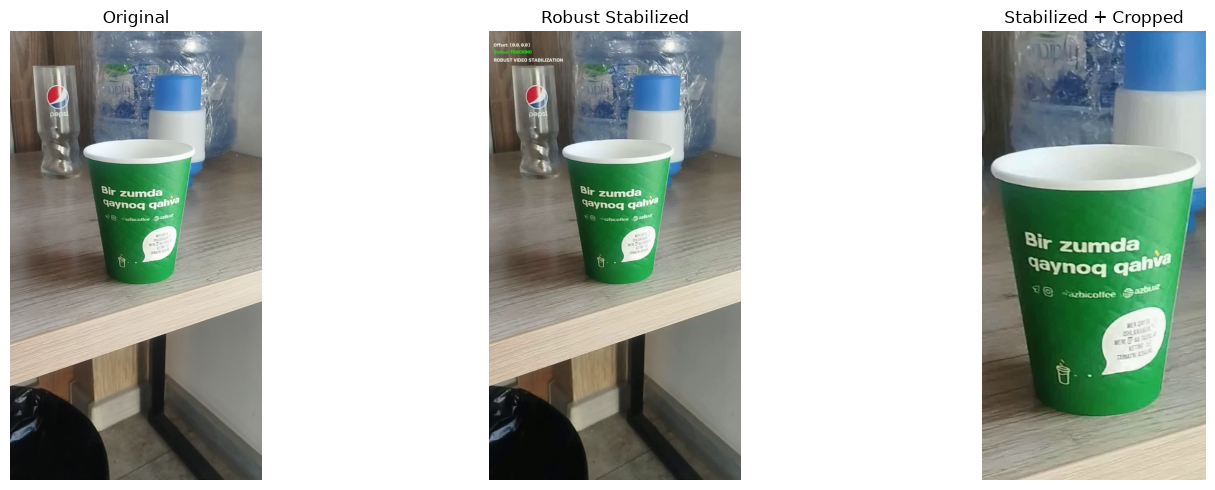

In [37]:
original = read_frame(
    VIDEO_PATH
)

stabilized = read_frame(
    STABILIZED_PATH
)

cropped = read_frame(
    CROPPED_PATH
)

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(stabilized)
plt.title("Robust Stabilized")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cropped)
plt.title("Stabilized + Cropped")
plt.axis("off")

plt.tight_layout()
plt.show()

In [38]:
print("DONE")
print("=" * 50)

print(
    f"Original:    {VIDEO_PATH}"
)

print(
    f"Stabilized:  {STABILIZED_PATH}"
)

print(
    f"Cropped:     {CROPPED_PATH}"
)

DONE
Original:    assets\cup.mp4
Stabilized:  outputs\cup_robust_stabilized.mp4
Cropped:     outputs\cup_robust_stabilized_cropped.mp4


```structure
First frame
    ↓
Select cup template
    ↓
Create search ROI
    ↓
Template matching
    ↓
Find cup movement
    ↓
Calculate frame-to-frame displacement
    ↓
Accumulate displacement
    ↓
Translate frame by negative cumulative offset
    ↓
Update template
    ↓
Update ROI
    ↓
Repeat
    ↓
Track min/max offsets
    ↓
Crop black borders
    ↓
Final stabilized video
```